# Phase I of the project: Training the model

I use STL-10 dataset which is a famous unlabeled dataset.

## The model with the highest accuracy so far is SimCLR, but since the neural network I am using is just a simple 2-layered NN, I can not use the weight vectors of the SimCLR model, but I can utilize in a way that it hints my NN what the photo might be probablisticly.  

In [1]:
import os
import shutil
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Configuration and loading the dataset
## Here I just train the dataset for 5 instances to achieve more accuracy

In [2]:
IMG_SIZE = 96
BATCH_SIZE = 48
INPUT_DIM = 96 * 96 * 3
HIDDEN_DIM = 8192
OUTPUT_DIM = 5
STUDENT_EPOCHS = 100
TEACHER_EPOCHS = 50
LR_STUDENT = 1e-3
TEMPERATURE = 4.0
ALPHA = 0.8
DRIVE_FOLDER = "weights3"
TARGET_CLASSES = ['airplane', 'bird', 'car', 'cat', 'dog']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Hardware: {device}")

def setup_drive():
    try:
        from google.colab import drive
        print("📂 Mounting Google Drive...")
        drive.mount('/content/drive')
        save_path = os.path.join('/content/drive/My Drive', DRIVE_FOLDER)
        if not os.path.exists(save_path):
            os.makedirs(save_path)
        return save_path
    except:
        return "."

SAVE_DIR = setup_drive()

#Dataset Filtering

class FilteredSTL10(Dataset):
    def __init__(self, root, split, transform=None, target_classes=None):
        self.dataset = torchvision.datasets.STL10(root=root, split=split, download=True, transform=transform)
        self.transform = transform

        #indices of target classes
        full_classes = self.dataset.classes
        target_indices = [full_classes.index(c) for c in target_classes]
        target_indices.sort() # Ensure consistent order

        #Old Index (e.g., 5 for dog) -> New Index (e.g., 4)
        self.label_map = {old: new for new, old in enumerate(target_indices)}
        self.new_class_names = [full_classes[i] for i in target_indices]

        self.valid_indices = []
        for idx, label in enumerate(self.dataset.labels):
            if label in target_indices:
                self.valid_indices.append(idx)

        print(f"   [{split}] Filtered {len(self.dataset)} -> {len(self.valid_indices)} images ({target_classes})")

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        original_idx = self.valid_indices[idx]
        img, label = self.dataset[original_idx]
        return img, self.label_map[label]

def get_dataloaders():
    print("📥 Preparing Data...")

    #Matches logic: (pixel / 255.0 - 0.5) / 0.5
    stats = ((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))

    train_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(*stats)
    ])

    test_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(*stats)
    ])

    train_set = FilteredSTL10(root='./data', split='train', transform=train_transform, target_classes=TARGET_CLASSES)
    test_set = FilteredSTL10(root='./data', split='test', transform=test_transform, target_classes=TARGET_CLASSES)

    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, test_loader, train_set.new_class_names


🚀 Hardware: cuda
📂 Mounting Google Drive...
Mounted at /content/drive


# Models & distillation loss function

In [3]:

class ResNetTeacher(nn.Module):
    def __init__(self, num_classes=5):
        super(ResNetTeacher, self).__init__()
        weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V2
        self.backbone = torchvision.models.resnet50(weights=weights)
        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(num_ftrs, num_classes)

    def forward(self, x):
        return self.backbone(x)

class StudentMLP(nn.Module):
    def __init__(self):
        super(StudentMLP, self).__init__()
        # Input: 96*96*3 = 27648
        # BIAS ENABLED: Improves fitting capability
        self.fc1 = nn.Linear(INPUT_DIM, HIDDEN_DIM, bias=True)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(HIDDEN_DIM, OUTPUT_DIM, bias=True)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# --- 3. Distillation Loss ---
def distillation_loss(student_logits, teacher_logits, labels, T, alpha):
    hard_loss = F.cross_entropy(student_logits, labels)
    soft_loss = nn.KLDivLoss(reduction="batchmean")(
        F.log_softmax(student_logits / T, dim=1),
        F.softmax(teacher_logits / T, dim=1)
    ) * (T * T)
    return alpha * soft_loss + (1.0 - alpha) * hard_loss

# Training ( pseudo transfer learning )

In [4]:
def train_teacher(model, train_loader, test_loader):
    print("\n👨‍🏫 --- PHASE 1: Super-Teacher Training ---")
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.AdamW([
        {'params': model.backbone.conv1.parameters(), 'lr': 1e-5},
        {'params': model.backbone.layer1.parameters(), 'lr': 1e-5},
        {'params': model.backbone.layer2.parameters(), 'lr': 1e-5},
        {'params': model.backbone.layer3.parameters(), 'lr': 5e-5},
        {'params': model.backbone.layer4.parameters(), 'lr': 5e-5},
        {'params': model.backbone.fc.parameters(), 'lr': 1e-3}
    ], weight_decay=1e-3)

    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=[1e-5, 1e-5, 1e-5, 5e-5, 5e-5, 1e-3],
                                              steps_per_epoch=len(train_loader), epochs=TEACHER_EPOCHS)

    best_acc = 0.0

    for epoch in range(TEACHER_EPOCHS):
        model.train()
        loop = tqdm(train_loader, desc=f"Teacher Ep {epoch+1}/{TEACHER_EPOCHS}", leave=False)
        for imgs, labels in loop:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            scheduler.step()
            loop.set_postfix(loss=loss.item())

        acc = evaluate(model, test_loader)
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), "best_teacher.pth")

    print(f"✅ Teacher Ready. Peak Accuracy: {best_acc:.2f}%")
    model.load_state_dict(torch.load("best_teacher.pth", map_location=device))
    model.eval()
    return model

def train_student(student, teacher, train_loader, test_loader):
    print("\n🎓 --- PHASE 2: Student Distillation ---")

    optimizer = optim.SGD(student.parameters(), lr=LR_STUDENT, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=8)

    best_acc = 0.0
    # Store weights AND biases
    best_weights = {'w1': None, 'b1': None, 'w2': None, 'b2': None}

    history = {'train_loss': [], 'test_acc': []}

    for epoch in range(STUDENT_EPOCHS):
        student.train()
        teacher.eval()

        total_loss = 0
        loop = tqdm(train_loader, desc=f"Student Ep {epoch+1}/{STUDENT_EPOCHS}", leave=False)

        for imgs, labels in loop:
            imgs, labels = imgs.to(device), labels.to(device)

            with torch.no_grad():
                teacher_logits = teacher(imgs)

            optimizer.zero_grad()
            student_logits = student(imgs)

            loss = distillation_loss(student_logits, teacher_logits, labels, TEMPERATURE, ALPHA)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            loop.set_postfix(loss=loss.item())

        acc = evaluate(student, test_loader)
        history['train_loss'].append(total_loss / len(train_loader))
        history['test_acc'].append(acc)

        scheduler.step(acc)

        print(f"   Epoch {epoch+1}: Acc {acc:.2f}% (Best: {max(best_acc, acc):.2f}%)")

        if acc > best_acc:
            best_acc = acc
            # Capture both Weights and Biases
            best_weights['w1'] = student.fc1.weight.detach().cpu().numpy()
            best_weights['b1'] = student.fc1.bias.detach().cpu().numpy()
            best_weights['w2'] = student.fc2.weight.detach().cpu().numpy()
            best_weights['b2'] = student.fc2.bias.detach().cpu().numpy()

    return history, best_weights, best_acc

def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total


# Helping utilities to upload to my Google drive

In [5]:
def plot_results(history):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Distillation Loss', color='purple')
    plt.title('Training Loss')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(history['test_acc'], label='Test Accuracy', color='green')
    plt.title('Student Accuracy (%)')
    plt.axhline(y=70, color='r', linestyle='--', label='Target (70%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('training_report.png')
    plt.show()


def export_weights(weights, accuracy):
    print(f"\n💾 Exporting weights/biases with Accuracy: {accuracy:.2f}%")

    #weights
    w1_t = weights['w1'].T.astype(np.float32)
    w2_t = weights['w2'].T.astype(np.float32)

    #biases (float32)
    b1 = weights['b1'].astype(np.float32)
    b2 = weights['b2'].astype(np.float32)

    files = {
        "w1.bin": w1_t,
        "b1.bin": b1,
        "w2.bin": w2_t,
        "b2.bin": b2
    }

    for filename, data in files.items():
        data.tofile(filename)

    #Drive
    if SAVE_DIR != ".":
        print(f"☁️ Uploading to Google Drive: {SAVE_DIR}")
        try:
            for filename in files.keys():
                shutil.copy(filename, os.path.join(SAVE_DIR, filename))

            shutil.copy('training_report.png', os.path.join(SAVE_DIR, "report.png"))
            print("✅ Upload Complete! (w1, b1, w2, b2)")
        except Exception as e:
            print(f"❌ Upload Failed: {e}")

# Execution

📥 Preparing Data...


100%|██████████| 2.64G/2.64G [00:49<00:00, 53.5MB/s]


   [train] Filtered 5000 -> 2500 images (['airplane', 'bird', 'car', 'cat', 'dog'])
   [test] Filtered 8000 -> 4000 images (['airplane', 'bird', 'car', 'cat', 'dog'])
Target Classes: ['airplane', 'bird', 'car', 'cat', 'dog']
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 185MB/s]



👨‍🏫 --- PHASE 1: Super-Teacher Training ---


...

   Epoch 96: Acc 59.58% (Best: 60.45%)


   Epoch 97: Acc 59.67% (Best: 60.45%)


   Epoch 98: Acc 59.52% (Best: 60.45%)


   Epoch 99: Acc 59.85% (Best: 60.45%)


   Epoch 100: Acc 60.60% (Best: 60.60%)


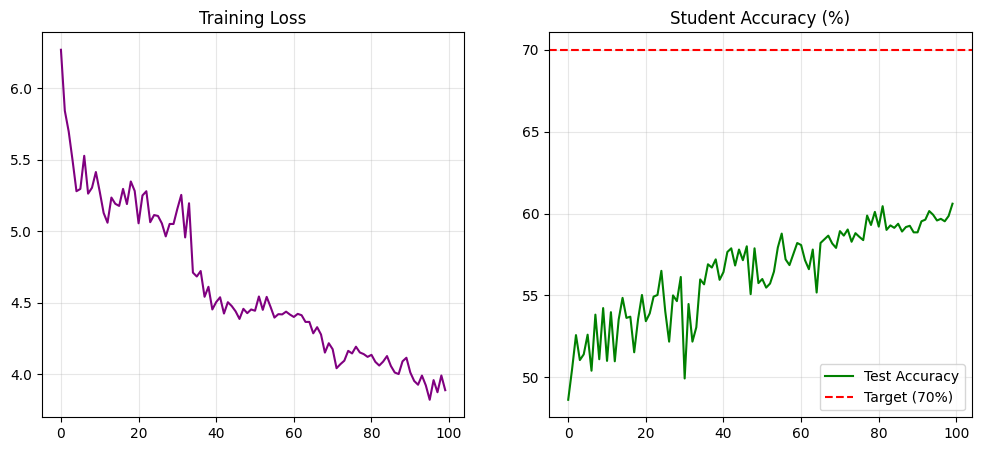


💾 Exporting weights/biases with Accuracy: 60.60%
☁️ Uploading to Google Drive: /content/drive/My Drive/weights3
✅ Upload Complete! (w1, b1, w2, b2)


In [6]:
def main():
    train_loader, test_loader, classes = get_dataloaders()
    print(f"Target Classes: {classes}")

    teacher = ResNetTeacher(num_classes=len(classes)).to(device)
    teacher = train_teacher(teacher, train_loader, test_loader)

    student = StudentMLP().to(device)
    history, best_weights, best_acc = train_student(student, teacher, train_loader, test_loader)

    plot_results(history)
    if best_weights['w1'] is not None:
        export_weights(best_weights, best_acc)
    else:
        print("Training failed to produce valid weights.")

if __name__ == "__main__":
    main()